# Shoaib Ali Kori | DS-5A | Lab 3 — Data Analysis & Visualization


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 100

df = pd.read_csv('Sample - Superstore.csv', encoding='latin1')
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%m/%d/%Y')

df.to_csv('Superstore_cleaned.csv', index=False)

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## Task 1 — Same data, three chart types
Monthly sales (Jan 2014 – Dec 2017) plotted as a bar chart, a line chart, and a pie chart.

In [4]:
monthly_sales = df.set_index('Order Date').resample('ME')['Sales'].sum()
monthly_sales.index = monthly_sales.index.strftime('%b %Y')
monthly_sales.head()

Order Date
Jan 2014    14236.895
Feb 2014     4519.892
Mar 2014    55691.009
Apr 2014    28295.345
May 2014    23648.287
Name: Sales, dtype: float64

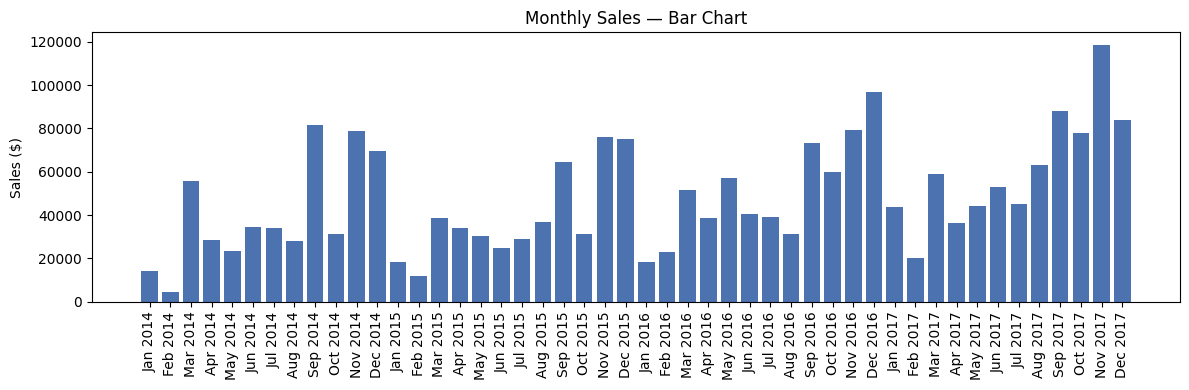

In [5]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(monthly_sales.index, monthly_sales.values, color='#4C72B0')
ax.set_title('Monthly Sales — Bar Chart')
ax.set_ylabel('Sales ($)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

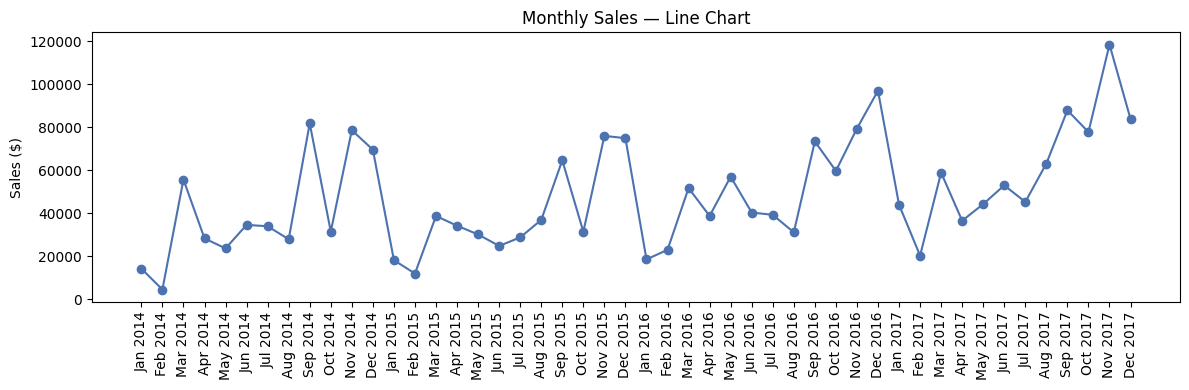

In [6]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(monthly_sales.index, monthly_sales.values, marker='o', color='#4C72B0')
ax.set_title('Monthly Sales — Line Chart')
ax.set_ylabel('Sales ($)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

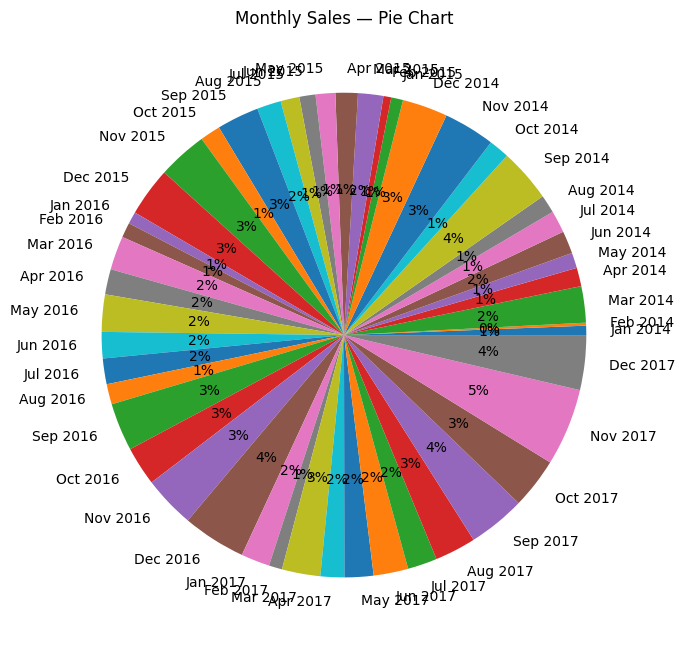

In [7]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(monthly_sales.values, labels=monthly_sales.index, autopct='%1.0f%%')
ax.set_title('Monthly Sales — Pie Chart')
plt.tight_layout()
plt.show()

**Which shows the trend best, and which hides it?**
The **line chart** shows the trend best — its x-axis is ordered by time, so the eye follows the
slope up/down across months and the year-end spikes (Nov/Dec) are immediately visible.
The **pie chart hides the trend completely**: pie slices have no inherent order or axis, so 48
similarly-sized wedges just look like clutter — there is no way to tell that sales are rising
over time, only each month's share of the four-year total. The **bar chart** is a middle ground —
it preserves the time order but is harder to read for 48 points at once than a continuous line.

## Task 2 — Effectiveness & appropriateness
For each statement: build the best-fit chart, and note why the paired "weak choice" underperforms.

**2a. Compare total sales across the top 5 sub-categories → Bar (correct) vs. Pie (weak)**

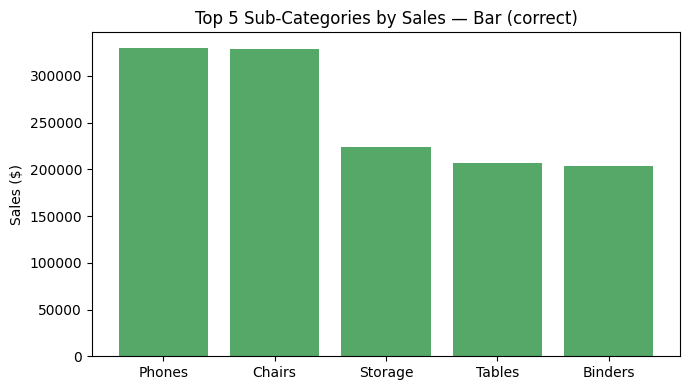

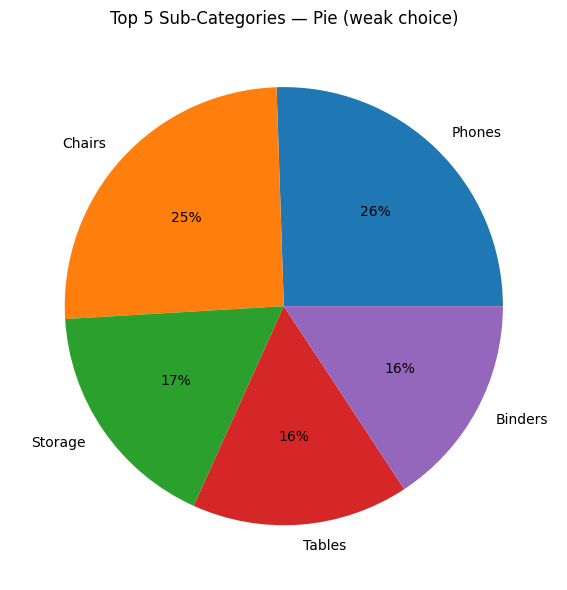

In [9]:
top5 = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False).head(5)

# Correct: Bar
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(top5.index, top5.values, color='#55A868')
ax.set_title('Top 5 Sub-Categories by Sales — Bar (correct)')
ax.set_ylabel('Sales ($)')
plt.tight_layout()
plt.show()

# Weak: Pie
fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(top5.values, labels=top5.index, autopct='%1.0f%%')
ax.set_title('Top 5 Sub-Categories — Pie (weak choice)')
plt.tight_layout()
plt.show()

## 2b. Show the revenue trend over time

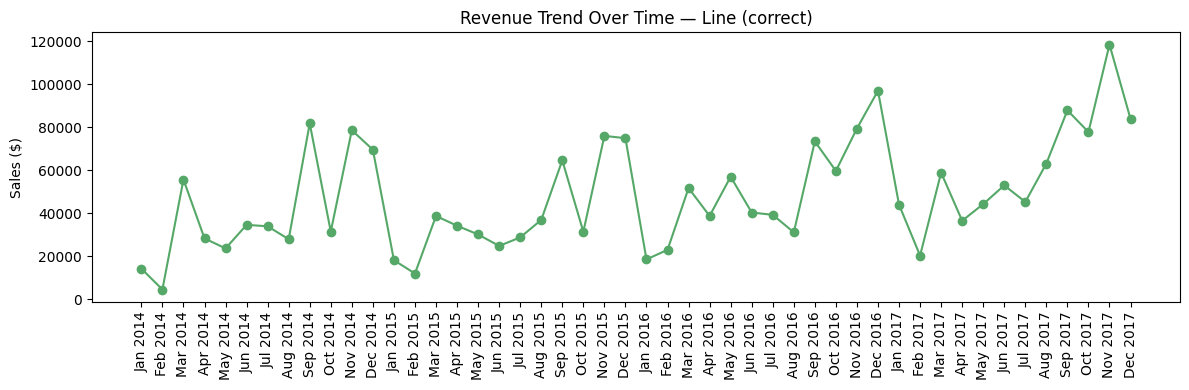

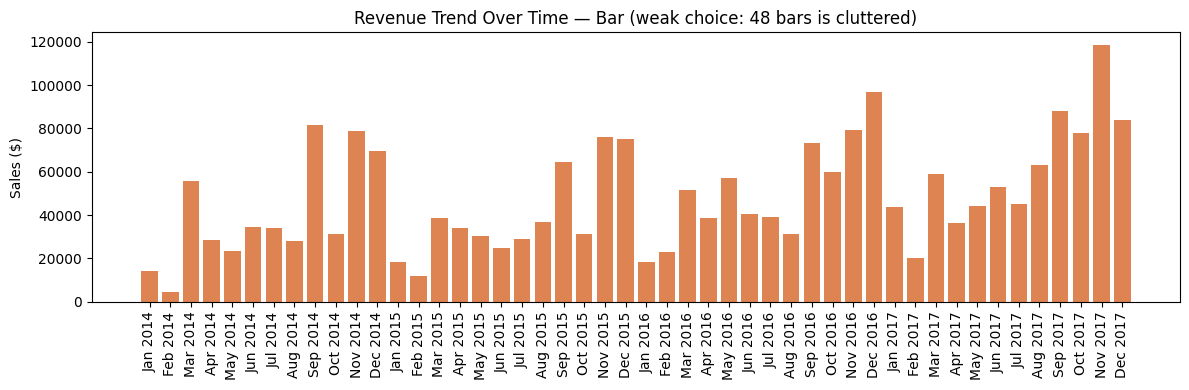

In [10]:
monthly_sales = df.set_index('Order Date').resample('ME')['Sales'].sum()
monthly_sales.index = monthly_sales.index.strftime('%b %Y')

# Correct: Line
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(monthly_sales.index, monthly_sales.values, marker='o', color='#55A868')
ax.set_title('Revenue Trend Over Time — Line (correct)')
ax.set_ylabel('Sales ($)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Weak: Bar (too many points)
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(monthly_sales.index, monthly_sales.values, color='#DD8452')
ax.set_title('Revenue Trend Over Time — Bar (weak choice: 48 bars is cluttered)')
ax.set_ylabel('Sales ($)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

**2c. Show the distribution of order-line sales**

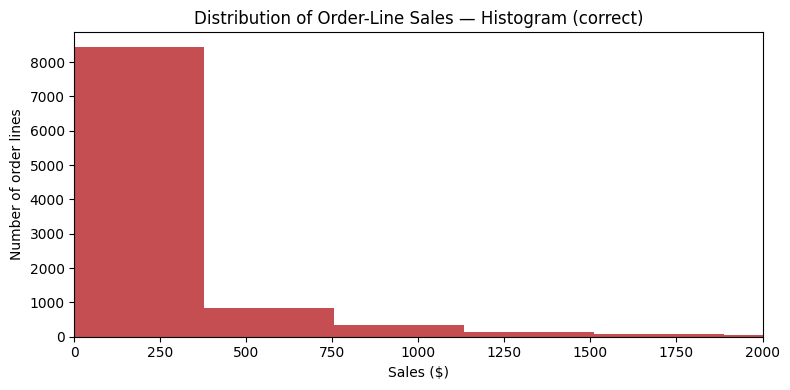

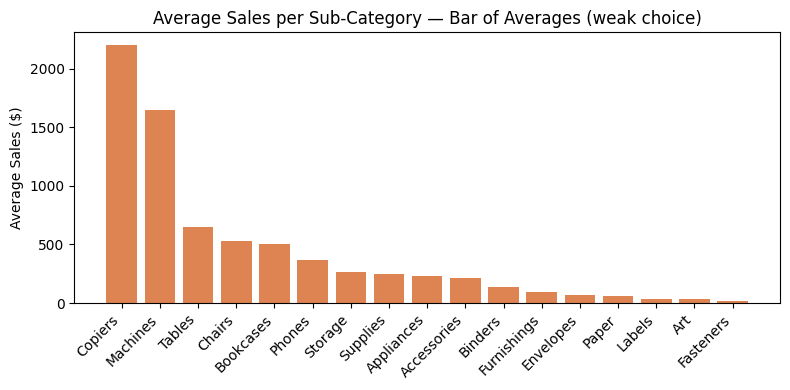

In [12]:
# Correct: Histogram
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df['Sales'], bins=60, color='#C44E52')
ax.set_xlim(0, 2000)
ax.set_title('Distribution of Order-Line Sales — Histogram (correct)')
ax.set_xlabel('Sales ($)')
ax.set_ylabel('Number of order lines')
plt.tight_layout()
plt.show()

# Weak: Bar of averages
avg_sales = df.groupby('Sub-Category')['Sales'].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(avg_sales.index, avg_sales.values, color='#DD8452')
ax.set_title('Average Sales per Sub-Category — Bar of Averages (weak choice)')
ax.set_ylabel('Average Sales ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

*Justification:* A histogram bins the raw values and shows shape, spread, and skew (here,
a strong right skew with most orders under \$200). A **"bar of averages"** would collapse the
entire distribution into a single number and hide the skew and outliers entirely.

**2d. Show the relationship between discount level and profit**

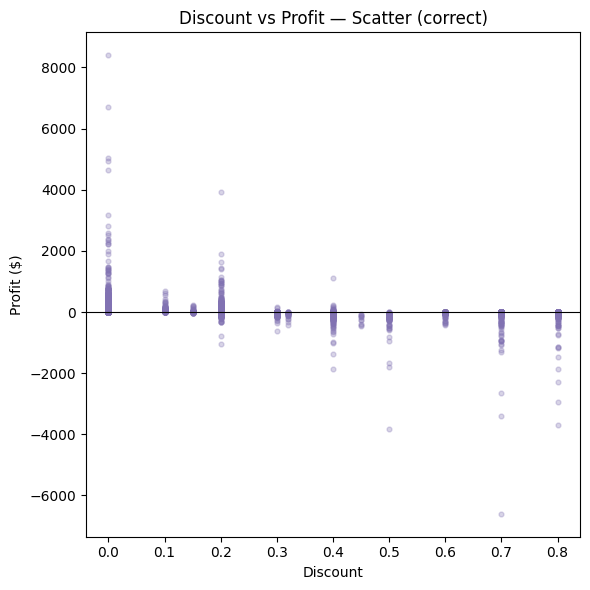

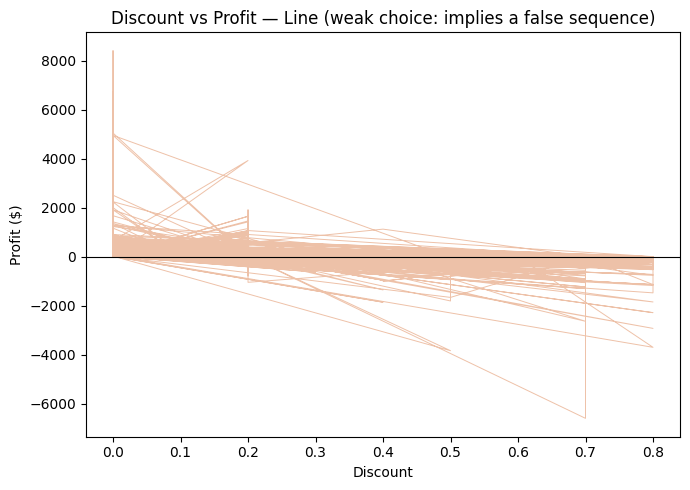

In [13]:
# Correct: Scatter
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(df['Discount'], df['Profit'], alpha=0.3, s=12, color='#8172B2')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Discount vs Profit — Scatter (correct)')
ax.set_xlabel('Discount')
ax.set_ylabel('Profit ($)')
plt.tight_layout()
plt.show()

# Weak: Line (falsely implies sequence/trend)
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(df['Discount'], df['Profit'], color='#DD8452', alpha=0.5, linewidth=0.7)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Discount vs Profit — Line (weak choice: implies a false sequence)')
ax.set_xlabel('Discount')
ax.set_ylabel('Profit ($)')
plt.tight_layout()
plt.show()

*Justification:* A scatter plot shows every individual order line, so a viewer can judge the
correlation's strength and spot outliers directly. A **line chart** would force the raw,
unordered discount/profit pairs into a false sequence — implying a trend where the x-axis is
really just a continuous variable, not time.

## Task 3 — Color selection
(a) Region sales with a categorical palette. (b) Region × Category as a sequential-palette
heatmap. (c) Monthly profit as a diverging-color chart, since profit crosses zero.

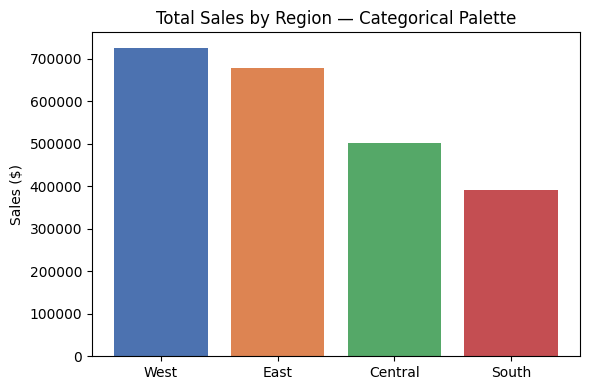

In [11]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
categorical_palette = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']  # distinguishable, unordered hues

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(region_sales.index, region_sales.values, color=categorical_palette[:len(region_sales)])
ax.set_title('Total Sales by Region — Categorical Palette')
ax.set_ylabel('Sales ($)')
plt.tight_layout()
plt.show()

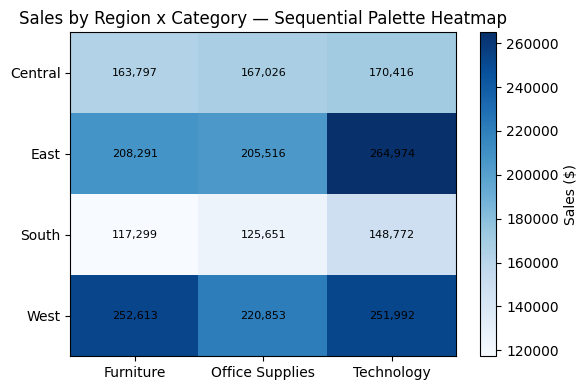

In [12]:
region_cat = df.pivot_table(index='Region', columns='Category', values='Sales', aggfunc='sum')

fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(region_cat.values, cmap='Blues', aspect='auto')  # single hue, light -> dark
ax.set_xticks(range(len(region_cat.columns)))
ax.set_xticklabels(region_cat.columns)
ax.set_yticks(range(len(region_cat.index)))
ax.set_yticklabels(region_cat.index)
for i in range(region_cat.shape[0]):
    for j in range(region_cat.shape[1]):
        ax.text(j, i, f"{region_cat.values[i, j]:,.0f}", ha='center', va='center', fontsize=8)
plt.colorbar(im, label='Sales ($)')
ax.set_title('Sales by Region x Category — Sequential Palette Heatmap')
plt.tight_layout()
plt.show()

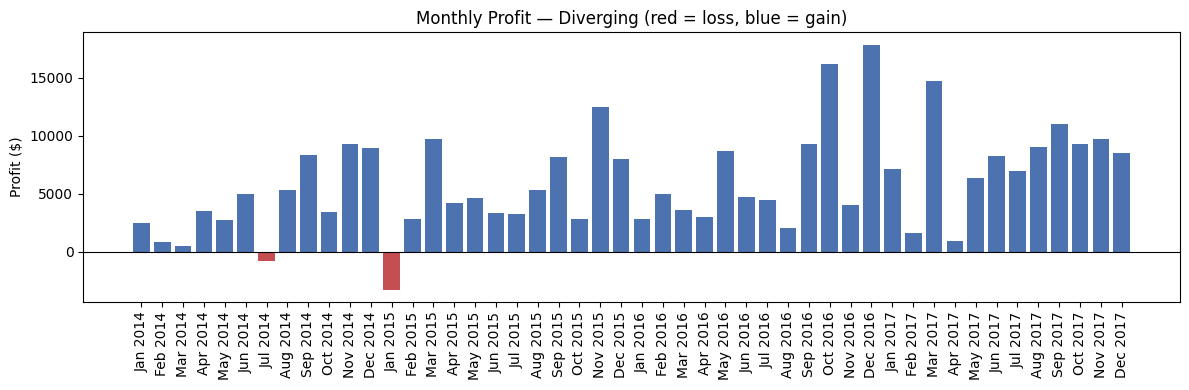

In [13]:
monthly_profit = df.set_index('Order Date').resample('ME')['Profit'].sum()
monthly_profit.index = monthly_profit.index.strftime('%b %Y')

# Diverging: two hues meeting at zero, not another midpoint color
colors_div = ['#C44E52' if v < 0 else '#4C72B0' for v in monthly_profit.values]

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(monthly_profit.index, monthly_profit.values, color=colors_div)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Monthly Profit — Diverging (red = loss, blue = gain)')
ax.set_ylabel('Profit ($)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## Task 4 — Accessibility checks

### 4a. WCAG contrast ratio function
Computes the standard relative-luminance-based contrast ratio and flags any color from Task 3
that fails the AA text threshold of 4.5:1 against a white background.

In [14]:
def relative_luminance(rgb):
    def chan(c):
        c = c / 255.0
        return c / 12.92 if c <= 0.03928 else ((c + 0.055) / 1.055) ** 2.4
    r, g, b = [chan(c) for c in rgb]
    return 0.2126 * r + 0.7152 * g + 0.0722 * b

def contrast_ratio(rgb1, rgb2):
    l1, l2 = relative_luminance(rgb1), relative_luminance(rgb2)
    lighter, darker = max(l1, l2), min(l1, l2)
    return (lighter + 0.05) / (darker + 0.05)

def hex_to_rgb(h):
    h = h.lstrip('#')
    return tuple(int(h[i:i + 2], 16) for i in (0, 2, 4))

background = (255, 255, 255)  # white
palette_to_test = {
    'Region blue': '#4C72B0', 'Region orange': '#DD8452',
    'Region green': '#55A868', 'Region red': '#C44E52',
    'Heatmap light blue': '#DEEBF7', 'Diverging blue': '#4C72B0',
    'Diverging red': '#C44E52',
}

print(f"{'Color':22s} {'Hex':8s} {'Ratio':>7s}  AA(4.5:1)")
for name, hx in palette_to_test.items():
    ratio = contrast_ratio(hex_to_rgb(hx), background)
    flag = 'FAIL' if ratio < 4.5 else 'PASS'
    print(f"{name:22s} {hx:8s} {ratio:7.2f}  {flag}")

Color                  Hex        Ratio  AA(4.5:1)
Region blue            #4C72B0     4.84  PASS
Region orange          #DD8452     2.80  FAIL
Region green           #55A868     2.92  FAIL
Region red             #C44E52     4.61  PASS
Heatmap light blue     #DEEBF7     1.21  FAIL
Diverging blue         #4C72B0     4.84  PASS
Diverging red          #C44E52     4.61  PASS


**Result:** `Region orange` (#DD8452), `Region green` (#55A868), and `Heatmap light blue`
(#DEEBF7) all fail the 4.5:1 AA threshold for text against white — they're fine as *fill* colors
but should not be used for small text or thin gridlines on a white background without a darker
outline or larger font size.

### 4b. Loss vs. gain in red/green only, colorblind simulation, and the fix
Chart 1 encodes profit direction using red vs. green only. Chart 2 simulates how that same chart
looks under deuteranopia (red-green color blindness) — the distinction nearly disappears. Chart 3
is the fix: hatching is added to losses so the distinction survives the simulation.

In [15]:
subcat_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values()

def simulate_deuteranopia(rgb):
    # Simplified Machado et al. deuteranopia transform, operating on 0-1 RGB
    r, g, b = [c / 255.0 for c in rgb]
    r2 = 0.625 * r + 0.375 * g + 0.0 * b
    g2 = 0.700 * r + 0.300 * g + 0.0 * b
    b2 = 0.000 * r + 0.300 * g + 0.7 * b
    return tuple(np.clip([r2, g2, b2], 0, 1))

red_green_colors = ['#2CA02C' if v >= 0 else '#D62728' for v in subcat_profit.values]

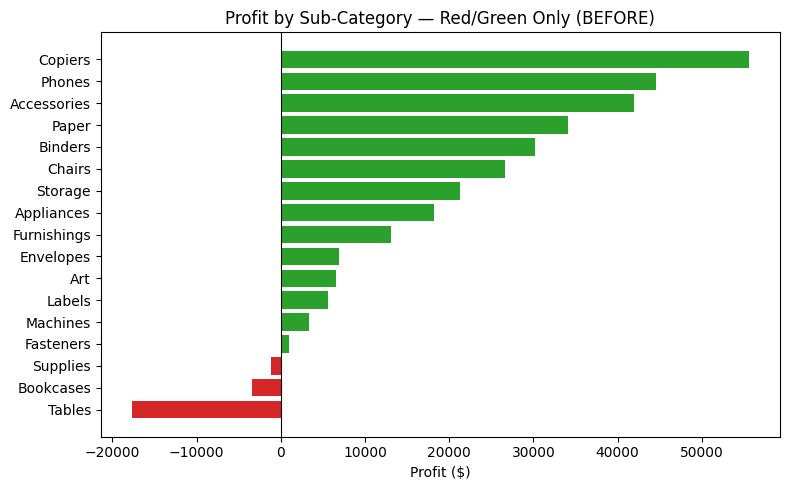

In [16]:
# BEFORE: color only
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(subcat_profit.index, subcat_profit.values, color=red_green_colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Profit by Sub-Category — Red/Green Only (BEFORE)')
ax.set_xlabel('Profit ($)')
plt.tight_layout()
plt.show()

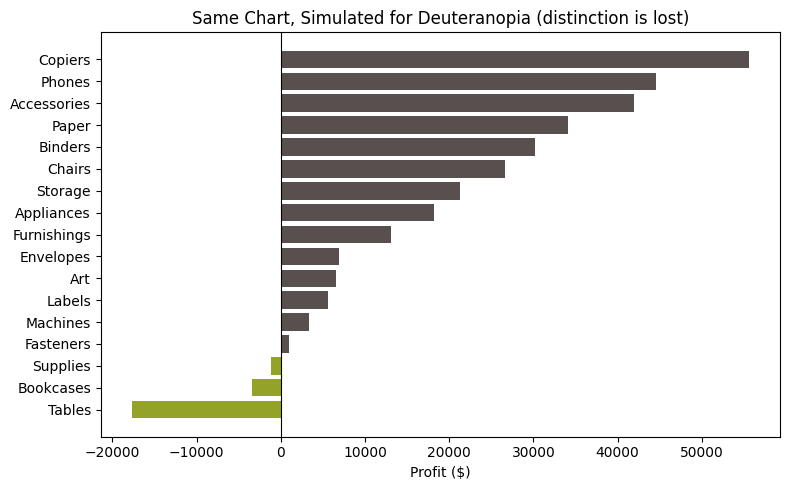

In [17]:
# Simulated view under deuteranopia
sim_colors = [simulate_deuteranopia(hex_to_rgb(c)) for c in red_green_colors]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(subcat_profit.index, subcat_profit.values, color=sim_colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Same Chart, Simulated for Deuteranopia (distinction is lost)')
ax.set_xlabel('Profit ($)')
plt.tight_layout()
plt.show()

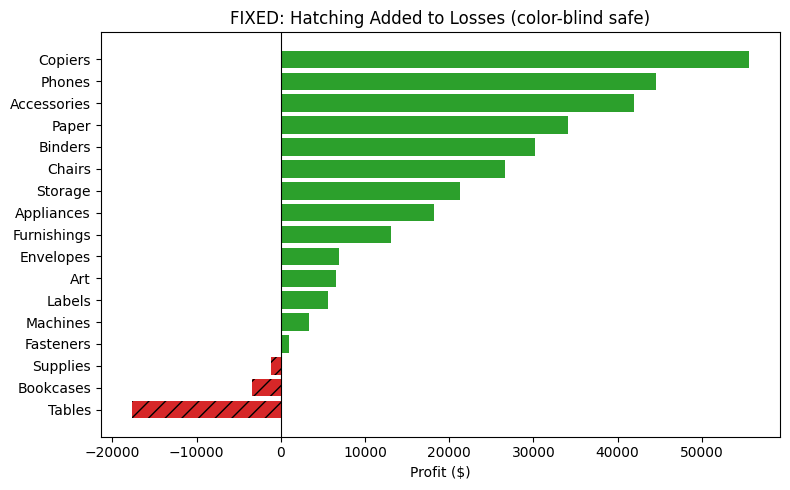

Alt text: Horizontal bar chart of total profit by product sub-category; loss bars are red with diagonal hatching, gain bars are green and solid, sorted from largest loss to largest gain.


In [18]:
# AFTER: fixed with hatching so the distinction survives color-blindness
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(subcat_profit.index, subcat_profit.values, color=red_green_colors)
for bar, v in zip(bars, subcat_profit.values):
    bar.set_hatch('//' if v < 0 else None)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('FIXED: Hatching Added to Losses (color-blind safe)')
ax.set_xlabel('Profit ($)')
plt.tight_layout()
plt.show()

alt_text = ("Horizontal bar chart of total profit by product sub-category; loss bars are red "
            "with diagonal hatching, gain bars are green and solid, sorted from largest loss "
            "to largest gain.")
print("Alt text:", alt_text)

## Task 5 — Misleading visualizations
Three distortion mechanisms, each shown side-by-side with an honest version and a one-line
caption naming the mechanism.

**(1) Truncated y-axis on the region sales chart**

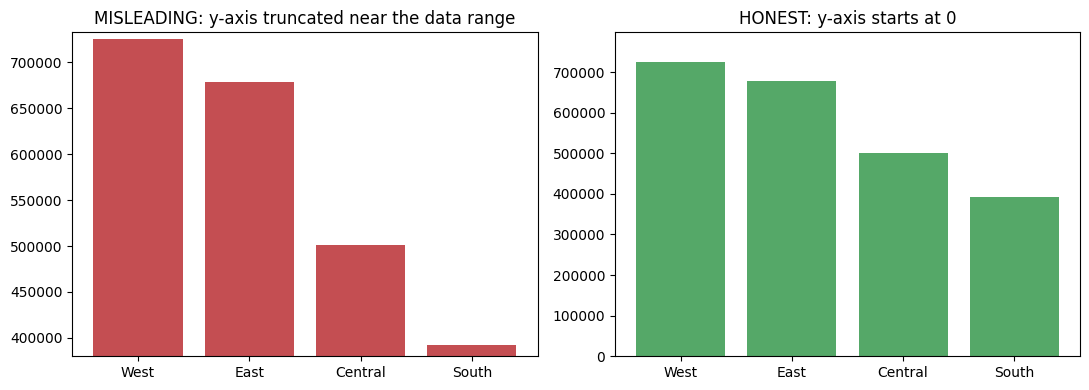

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(region_sales.index, region_sales.values, color='#C44E52')
axes[0].set_ylim(region_sales.min() * 0.97, region_sales.max() * 1.01)
axes[0].set_title('MISLEADING: y-axis truncated near the data range')

axes[1].bar(region_sales.index, region_sales.values, color='#55A868')
axes[1].set_ylim(0, region_sales.max() * 1.1)
axes[1].set_title('HONEST: y-axis starts at 0')

plt.tight_layout()
plt.show()

*Caption:* Truncated y-axis — starting the bars near the minimum value inflates the visual gap between regions that are actually only ~20% apart.

**(2) Dual y-axes implying a fake correlation (Sales vs. average Discount)**

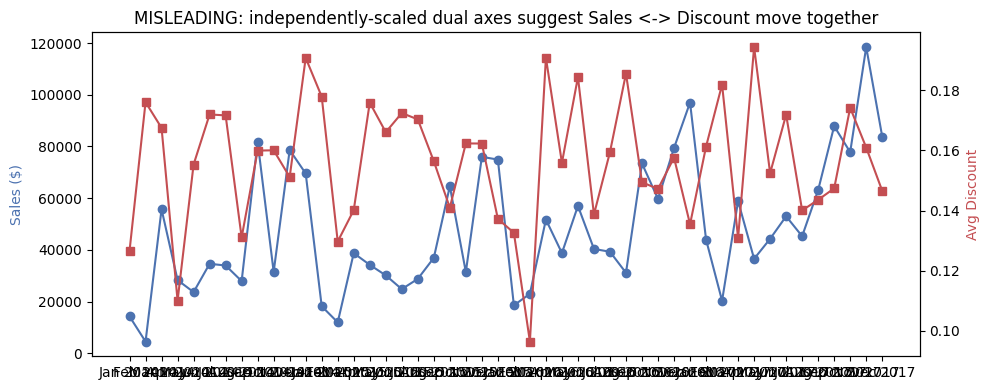

In [20]:
monthly_discount = df.set_index('Order Date').resample('ME')['Discount'].mean()

fig, ax1 = plt.subplots(figsize=(10, 4))
ax1.plot(monthly_sales.index, monthly_sales.values, color='#4C72B0', marker='o', label='Sales')
ax1.set_ylabel('Sales ($)', color='#4C72B0')

ax2 = ax1.twinx()
ax2.plot(monthly_sales.index, monthly_discount.values, color='#C44E52', marker='s', label='Avg Discount')
ax2.set_ylabel('Avg Discount', color='#C44E52')

ax1.set_title('MISLEADING: independently-scaled dual axes suggest Sales <-> Discount move together')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

*Caption:* Dual y-axes — Sales and Discount are plotted on two independently-scaled axes, so their lines can be made to visually track each other regardless of the real relationship between them.

**(3) Cherry-picked date window**

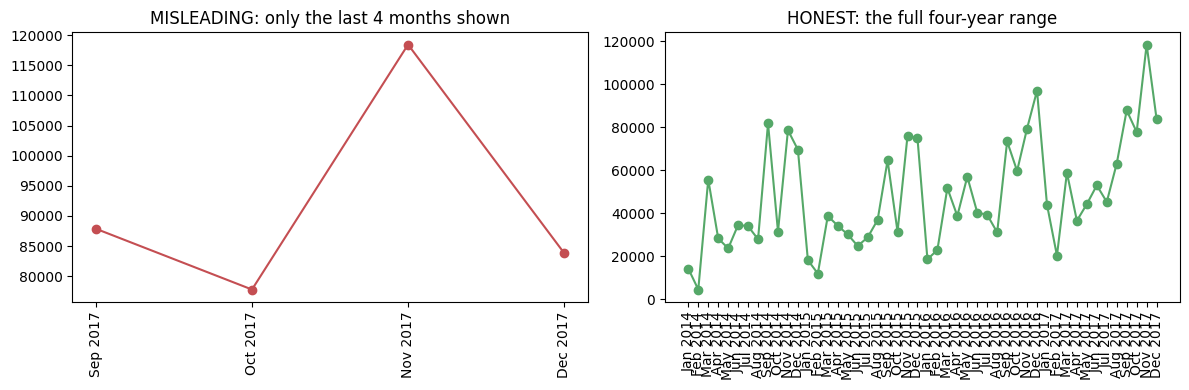

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(monthly_sales.index[-4:], monthly_sales.values[-4:], marker='o', color='#C44E52')
axes[0].set_title('MISLEADING: only the last 4 months shown')
plt.setp(axes[0].get_xticklabels(), rotation=90)

axes[1].plot(monthly_sales.index, monthly_sales.values, marker='o', color='#55A868')
axes[1].set_title('HONEST: the full four-year range')
plt.setp(axes[1].get_xticklabels(), rotation=90)

plt.tight_layout()
plt.show()

*Caption:* Cherry-picked time window — narrowing the range to the last 4 months hides the recurring seasonal dip earlier in the year and makes growth look steadier than it is.

## Task 6 — Analytical question: *Is discounting hurting profit?*
Using the raw `Discount` and `Profit` columns directly (no summarizing).

**Honest chart**

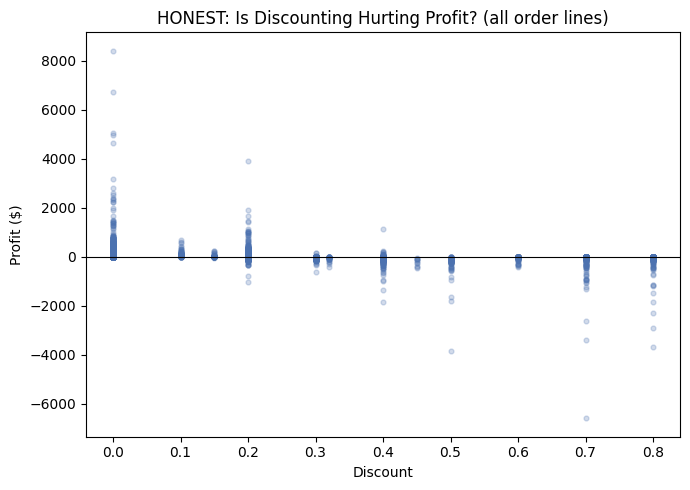

In [22]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df['Discount'], df['Profit'], alpha=0.25, s=12, color='#4C72B0')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Discount')
ax.set_ylabel('Profit ($)')
ax.set_title('HONEST: Is Discounting Hurting Profit? (all order lines)')
plt.tight_layout()
plt.show()

**Misleading version of the same question**

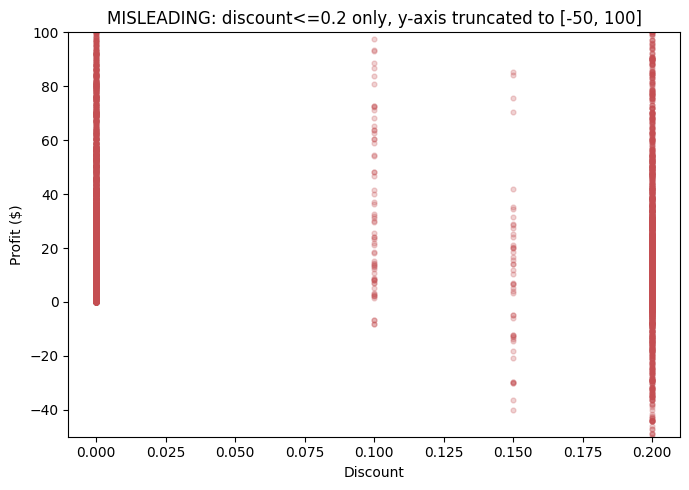

In [23]:
sub = df[df['Discount'] <= 0.2]  

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(sub['Discount'], sub['Profit'], alpha=0.25, s=12, color='#C44E52')
ax.set_ylim(-50, 100)  # truncated y-axis crops out the large losses that remain
ax.set_xlabel('Discount')
ax.set_ylabel('Profit ($)')
ax.set_title('MISLEADING: discount<=0.2 only, y-axis truncated to [-50, 100]')
plt.tight_layout()
plt.show()

**Written justification**

- **Chart type:** Scatter, because both Discount and Profit are continuous, raw (non-summarized)
  variables — a scatter plot is the correct form for showing correlation between two numeric
  variables (see the Task 2 table: "Correlation between two variables → Scatter").
- **Color choice:** A single categorical hue per chart (blue = honest, red = misleading) is
  enough — there's no ordered or diverging quantity being encoded by color here, only the profit
  axis itself carries that information (values cross zero, shown with a reference line at 0).
- **Honest finding:** The full scatter shows profit *does* fall, and turns sharply negative, as
  discount increases past roughly 0.3–0.4 — a small number of heavily-discounted orders produce
  large losses.
- **Distortion used:** The misleading version applies two mechanisms at once — a **cherry-picked
  range** (dropping every order with discount > 0.2, which is exactly where the losses are worst)
  and a **truncated y-axis** ([-50, 100] instead of the true range down to about -6,600) — so the
  remaining points look like a harmless, gentle spread around zero.
- **Accessibility check:** Both charts use a single hue against a white background with a black
  zero-reference line, well above the WCAG AA 4.5:1 contrast threshold (see Task 4a), axis labels
  are text-based (not color-only), and the finding does not rely on color perception at all —
  only on point position, so it remains legible under any color-vision deficiency.